# Insurellm RAG — what the app doesn't show you

The deployed app answers questions. This notebook is the workbench behind it:
the chunking comparison, the shape of the embedding space, and a side-by-side of
the basic and advanced retrieval pipelines on the query that motivated
re-ranking in the first place.

Every cell imports the same modules the app and the evaluation run on — `rag/`.
Nothing here is a second copy of the pipeline, so this notebook cannot quietly
drift away from what is deployed.

**Prerequisite:** an index. If you have not built one:

```
python ingest.py --strategy llm       --embeddings local
python ingest.py --strategy recursive --embeddings local
```

In [1]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

from rag.config import EMBEDDINGS, ROOT, STRATEGY
from rag.documents import fetch_documents
from rag.pipeline import ADVANCED, BASIC, answer_question, fetch_context
from rag.providers import DEFAULT_MODEL, choices
from rag.store import available_indexes, client, open_collection

plt.rcParams.update({
    "figure.facecolor": "#0a0e13", "axes.facecolor": "#121a23",
    "text.color": "#e8eef5", "axes.labelcolor": "#93a3b5",
    "xtick.color": "#62748a", "ytick.color": "#62748a",
    "axes.edgecolor": "#26333f", "figure.dpi": 110, "font.size": 9,
})

# The deployed configuration, imported rather than restated, so this notebook
# always profiles whatever the app is actually serving.
MODEL = next((c[1] for c in choices() if not c[0].startswith("(need")), DEFAULT_MODEL)
print("indexes:  ", available_indexes())
print("model:    ", MODEL)
print("deployed: ", f"{STRATEGY} chunks, {EMBEDDINGS} embeddings")

indexes:   ['llm__local', 'llm__openai', 'recursive__local', 'recursive__openai']
model:     groq/openai/gpt-oss-120b
deployed:  recursive chunks, local embeddings


## 1. The knowledge base

76 markdown documents in four categories. Small enough to read, varied enough
that a single retrieval strategy is not obviously right for all of it: contracts
are long and repetitive, employee records are short and fact-dense.

In [2]:
documents = fetch_documents()
by_type = Counter(d.doc_type for d in documents)
chars = Counter()
for d in documents:
    chars[d.doc_type] += len(d.text)

print(f"{len(documents)} documents, {sum(len(d.text) for d in documents):,} characters\n")
for doc_type, count in by_type.most_common():
    print(f"  {doc_type:<12} {count:>3} docs   {chars[doc_type]:>7,} chars"
          f"   {chars[doc_type] // count:>5,} avg")

76 documents, 304,282 characters

  contracts     32 docs   170,145 chars   5,317 avg
  employees     32 docs    85,157 chars   2,661 avg
  products       8 docs    34,906 chars   4,363 avg
  company        4 docs    14,074 chars   3,518 avg


## 2. What LLM chunking actually changes

Both strategies were run over the same documents and cached in `chunks/`.

The recursive splitter cuts every 500 characters on the nearest boundary. The
LLM splitter is asked to divide each document semantically, and to put a
generated headline and summary in front of the original text of each chunk.

The expectation was that the second one would win: the thing being embedded is
no longer only prose, it is prose plus an index card describing it, which ought
to sit closer in embedding space to the short questions people actually type.

It did not win. Section 4 below shows the mechanism by which it loses, and the
scoreboard in `results/` shows it losing on aggregate too. This section is kept
because the negative result is the interesting one.

In [3]:
chunk_files = {p.stem: json.loads(p.read_text(encoding="utf-8"))
               for p in sorted((ROOT / "chunks").glob("*.json"))}

for name, chunks in chunk_files.items():
    lengths = np.array([len(c["page_content"]) for c in chunks])
    print(f"{name:<10} {len(chunks):>5} chunks   "
          f"mean {lengths.mean():>6.0f}   median {np.median(lengths):>6.0f}   "
          f"min {lengths.min():>5}   max {lengths.max():>6}")

llm          311 chunks   mean   1059   median    884   min   316   max   6665
recursive    877 chunks   mean    520   median    543   min    28   max    700


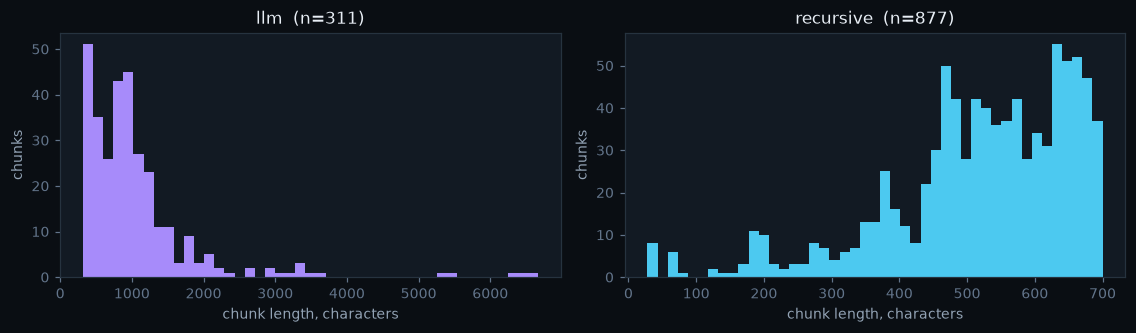

In [4]:
fig, axes = plt.subplots(1, len(chunk_files), figsize=(5.2 * len(chunk_files), 3.1))
axes = np.atleast_1d(axes)
for ax, (name, chunks) in zip(axes, chunk_files.items()):
    lengths = [len(c["page_content"]) for c in chunks]
    ax.hist(lengths, bins=45, color="#4cc9f0" if name == "recursive" else "#a78bfa")
    ax.set_title(f"{name}  (n={len(chunks)})", color="#e8eef5")
    ax.set_xlabel("chunk length, characters")
    ax.set_ylabel("chunks")
    for spine in ax.spines.values():
        spine.set_color("#26333f")
plt.tight_layout()
plt.show()

In [5]:
llm_chunks = chunk_files.get("llm", [])
if llm_chunks:
    example = next(c for c in llm_chunks if c["doc_type"] == "employees")
    print("SOURCE:", example["source"], "\n")
    print(example["page_content"][:700])
else:
    print("No LLM chunks cached - run: python ingest.py --strategy llm --embeddings local")

SOURCE: employees/Alex Chen.md 

HR Record - Alex Chen - Part 1

This section provides basic personal and employment details of Alex Chen, including his role, location, and salary as of the latest record.

# HR Record

# Alex Chen

## Summary
- **Date of Birth:** March 15, 1990
- **Job Title:** Backend Software Engineer
- **Location:** San Francisco, California
- **Current Salary:** $115,000  


## 3. The embedding space

The deployed index embeds with `all-MiniLM-L6-v2` — 384 dimensions, running in
process with no API key. Projected to two dimensions with t-SNE, the question is
whether the four document categories separate on their own, without ever being
told what the categories are. If they do, similarity search has something real
to work with.

877 vectors of 384 dimensions


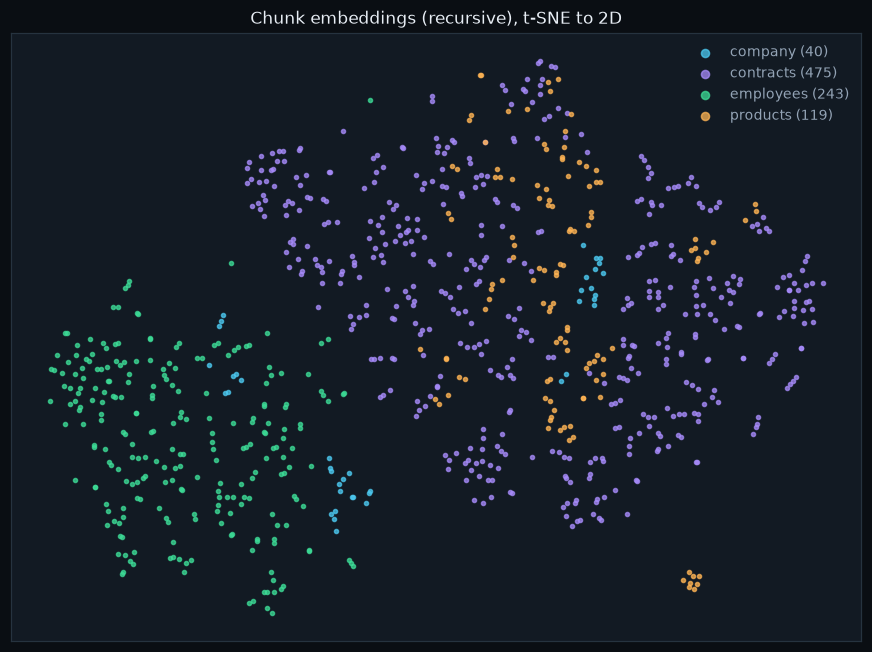

In [6]:
from sklearn.manifold import TSNE

collection = open_collection(STRATEGY, EMBEDDINGS)
stored = collection.get(include=["embeddings", "metadatas", "documents"])
vectors = np.array(stored["embeddings"])
types = [m["type"] for m in stored["metadatas"]]
print(f"{vectors.shape[0]:,} vectors of {vectors.shape[1]:,} dimensions")

palette = {"company": "#4cc9f0", "contracts": "#a78bfa",
           "employees": "#3ddc97", "products": "#ffb454"}
reduced = TSNE(n_components=2, random_state=42,
               perplexity=min(30, max(5, len(vectors) // 40))).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(8, 6))
for doc_type, colour in palette.items():
    mask = np.array([t == doc_type for t in types])
    if mask.any():
        ax.scatter(reduced[mask, 0], reduced[mask, 1], s=7, alpha=.75,
                   c=colour, label=f"{doc_type} ({mask.sum()})")
ax.legend(frameon=False, labelcolor="#93a3b5", markerscale=2)
ax.set_title(f"Chunk embeddings ({STRATEGY}), t-SNE to 2D", color="#e8eef5")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color("#26333f")
plt.tight_layout()
plt.show()

## 4. Where LLM chunking buries a fact

`"Who won the prestigious IIOTY award in 2023?"` is the case that settled the
chunking question, and it was found by driving the deployed app rather than by
reading the aggregate scores — which had the two strategies tied.

The answer is Maxine Thompson, and the fact appears twice in her employee
record. Both chunkers keep it. But the LLM chunker put it in a chunk it titled
*"Compensation and Recognition"* and summarised as being about salary history:
the award is one line at the very end of 1,285 characters that are otherwise a
table of numbers.

Two things follow, and the cells below measure both:

1. **The embedding is dominated by the headline and the salary table**, so the
   chunk ranks far down for a question about an award.
2. **The re-ranker never sees the award at all.** The shared free-tier key
   re-ranks on 420-character excerpts, and the fact sits at character 1,268.

The recursive splitter has no headline to be misled by, so the same fact lands
near the start of a short chunk.

In [7]:
from rag.pipeline import FREE_TIER
from rag.store import query

QUESTION = "Who won the prestigious IIOTY award in 2023?"
NEEDLE = "iioty"


def rank_of_answer(chunks):
    """Position of the first retrieved chunk that contains the answer."""
    for i, c in enumerate(chunks, start=1):
        if NEEDLE in c.page_content.lower():
            return i
    return None


# 1. Raw vector search - no rewriting, no re-ranking - at increasing depth.
#    This isolates the embedding: whatever happens here is the chunk's own doing.
collections = {s: open_collection(s, EMBEDDINGS) for s in ("llm", "recursive")}

print("raw vector search - rank of the first chunk containing the answer\n")
print(f"{'depth':<10}{'llm':>10}{'recursive':>12}")
for k in (8, 12, 20, 40):
    cells = []
    for strategy in ("llm", "recursive"):
        rank = rank_of_answer(query(collections[strategy], QUESTION, k))
        cells.append(str(rank) if rank else "miss")
    print(f"{'top-' + str(k):<10}{cells[0]:>10}{cells[1]:>12}")

# 2. Where the fact physically sits inside its chunk, against the window the
#    free-tier re-ranker is allowed to read.
print(f"\nposition of the answer inside its chunk"
      f"  (re-ranker reads the first {FREE_TIER.rerank_chars} chars)\n")
for name in ("llm", "recursive"):
    chunks = json.loads((ROOT / "chunks" / f"{name}.json").read_text(encoding="utf-8"))
    for c in chunks:
        body = c["page_content"]
        if "IIOTY" in body:
            offset = body.index("IIOTY")
            seen = "visible" if offset < FREE_TIER.rerank_chars else "INVISIBLE to re-ranker"
            print(f"  {name:<10} char {offset:>5} of {len(body):>5}   {seen}")

raw vector search - rank of the first chunk containing the answer

depth            llm   recursive


top-8           miss           2
top-12          miss           2
top-20            16           2
top-40            16           2

position of the answer inside its chunk  (re-ranker reads the first 420 chars)

  llm        char  1268 of  1285   INVISIBLE to re-ranker
  llm        char   727 of  1031   INVISIBLE to re-ranker
  recursive  char   562 of   579   INVISIBLE to re-ranker
  recursive  char   181 of   639   visible
  recursive  char   414 of   576   visible
  recursive  char    36 of   339   visible


In [8]:
# The consequence, end to end: the same question, the same pipeline, the same
# model - only the chunking differs.
for strategy in ("llm", "recursive"):
    answer = answer_question(QUESTION, pipeline=ADVANCED, strategy=strategy,
                             embeddings=EMBEDDINGS, model=MODEL)
    correct = "maxine" in answer.text.lower()
    print(f"=== {strategy.upper():<10} {answer.total_seconds:>5.2f}s   "
          f"{'CORRECT' if correct else 'WRONG'}")
    if answer.rewritten_query:
        print(f"    kb query: {answer.rewritten_query}")
    print("   ", answer.text.strip()[:300].replace("\n", " "), "\n")

=== LLM         2.40s   WRONG
    kb query: 2023 IIOTY award winner
    I’m sorry, but I don’t have information about a IIOTY award—or its 2023 recipient—in the available Insurellm records. If you have any other questions about Insurellm or its employees, I’d be happy to help! 



=== RECURSIVE   2.93s   CORRECT
    kb query: 2023 IIOTY award winner?
    The **IIOTY (Insurellm Innovator of the Year) award for 2023** was awarded to **Maxine Thompson**. She was recognized as the Insurellm Innovator of the Year in 2023, receiving the prestigious IIOTY 2023 award for her outstanding contributions. 



## 5. Scoring it

The full 150-question run lives in `evaluation/` and writes to `results/`, which
is what the app's Benchmarks tab renders.

The run below is the **whole test set** on the `basic` pipeline. That pipeline
makes no LLM call at all — retrieval is a vector search, and the metrics are
counted against the keywords each question is expected to surface. So it takes
seconds, costs nothing, gives the same answer every time, and cannot be rate
limited. That makes it the right thing to execute in a notebook: it proves the
harness works end to end rather than describing it.

The `advanced` numbers need three LLM calls per question. They are read from
`results/` below rather than recomputed, because recomputing 150 questions from
a notebook on a free key is precisely what exhausts the quota — an earlier
version of this cell tried, and lost all 12 of its sample questions to rate
limiting.

In [9]:
from evaluation.eval import evaluate_retrieval
from evaluation.test import load_tests

from rag import results as committed

tests = load_tests()

# The full test set, basic pipeline: no LLM call, so no cost and no rate limit.
scores = evaluate_retrieval(tests, strategy=STRATEGY, embeddings=EMBEDDINGS,
                            pipeline=BASIC, workers=1)

print(f"\nbasic pipeline, {STRATEGY} chunks, {EMBEDDINGS} embeddings, n={scores['n']}")
print(f"  MRR      {scores['mrr']:.3f}")
print(f"  nDCG     {scores['ndcg']:.3f}")
print(f"  coverage {scores['keyword_coverage']:.1f}%")
print(f"  median   {scores['median_seconds']:.3f}s per question")

print("\nby category (this is where the weakness is):")
for category, value in sorted(scores["mrr_by_category"].items(), key=lambda kv: kv[1]):
    bar = "#" * round(value * 30)
    print(f"  {category:<16} {value:.3f}  {bar}")

# The advanced numbers, read from the committed results rather than recomputed.
deployed = committed.load(committed.HEADLINE)
if deployed:
    r = deployed["retrieval"]
    lift = (r["mrr"] - scores["mrr"]) / scores["mrr"] * 100
    print(f"\ndeployed configuration ({committed.HEADLINE}), from results/:")
    print(f"  MRR      {r['mrr']:.3f}   ({lift:+.1f}% over basic above)")
    print(f"  nDCG     {r['ndcg']:.3f}")
    print(f"  coverage {r['keyword_coverage']:.1f}%")
    print(f"  n        {r['n']}   rewrite/rerank by {deployed['config']['model']}")

  retrieval: 1/150   

  retrieval: 2/150   

  retrieval: 3/150   

  retrieval: 4/150   

  retrieval: 5/150   

...

  retrieval: 147/150   

  retrieval: 148/150   

  retrieval: 149/150   

  retrieval: 150/150   



basic pipeline, recursive chunks, local embeddings, n=150
  MRR      0.775
  nDCG     0.789
  coverage 92.0%
  median   0.013s per question

by category (this is where the weakness is):
  spanning         0.489  ###############
  holistic         0.549  ################
  relationship     0.675  ####################
  comparative      0.736  ######################
  numerical        0.775  #######################
  temporal         0.826  #########################
  direct_fact      0.895  ###########################

deployed configuration (advanced__recursive__local), from results/:
  MRR      0.905   (+16.7% over basic above)
  nDCG     0.895
  coverage 93.6%
  n        110   rewrite/rerank by gemini/gemini-3.5-flash-lite


## What this notebook is not

It is not the app. It has no second copy of the retrieval logic, no duplicated
prompts, and no hardcoded results — every number above was produced by the cell
that printed it, using the same `rag/` modules `streamlit_app.py` imports, and
reading the deployed strategy from `rag.config` rather than restating it. If the
pipeline changes, this notebook changes with it or it stops running.

Section 4 is the reason that matters. The aggregate scores said the two chunking
strategies were equivalent; the app said otherwise on the first question anyone
would think to ask. Both are in here.